In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [2]:
# -----------------------------
# Load dataset
# -----------------------------
file_path = "Z:/Machine_learning Dr. Vimina/Machine Learning 2026/BCA H 2026/ML Lab Programs/car_evaluation.csv"

data = pd.read_csv(file_path)

print("Original Dataset")
print(data.head())

Original Dataset
  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc


In [3]:
print(data.describe())

       buying  maint doors persons lug_boot safety  class
count    1728   1728  1728    1728     1728   1728   1728
unique      4      4     4       3        3      3      4
top     vhigh  vhigh     2       2    small    low  unacc
freq      432    432   432     576      576    576   1210


In [4]:
# Separate features (X) and target (y)
X = data.drop(columns=['class'])
y = data['class']

In [5]:
# 2. Pre-process Categorical Features
# Since all features are ordinal/categorical, we use OrdinalEncoder to preserve implicit ordering
encoder = OrdinalEncoder()
X_encoded = pd.DataFrame(encoder.fit_transform(X), columns=X.columns)

In [6]:
# -----------------------------
# 3.Train-Test Split
# -----------------------------
# Train-Test Split (80% Train, 20% Test with Stratification)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
# 4. Create Decision Tree
dt = DecisionTreeClassifier(criterion="entropy",max_depth=4,random_state=42)

In [8]:
# --------------------------------------------------
# 4. Train the model
# --------------------------------------------------
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [9]:
# --------------------------------------------------
# 5. Make predictions
# --------------------------------------------------

y_pred = dt.predict(X_test)

In [10]:
# Evaluate the model
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.815028901734104

Confusion Matrix:
[[ 67   0  10   0]
 [ 14   0   0   0]
 [ 27   0 215   0]
 [ 13   0   0   0]]

Classification Report:
              precision    recall  f1-score   support

         acc       0.55      0.87      0.68        77
        good       0.00      0.00      0.00        14
       unacc       0.96      0.89      0.92       242
       vgood       0.00      0.00      0.00        13

    accuracy                           0.82       346
   macro avg       0.38      0.44      0.40       346
weighted avg       0.79      0.82      0.79       346



c:\Users\viminaer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\viminaer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\viminaer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

In [11]:
# 6. Print Text Rules of the Decision Tree
print("--- Decision Tree Structure ---")
print(export_text(dt, feature_names=list(X.columns)))

--- Decision Tree Structure ---
|--- persons <= 0.50
|   |--- class: unacc
|--- persons >  0.50
|   |--- safety <= 0.50
|   |   |--- buying <= 2.50
|   |   |   |--- buying <= 0.50
|   |   |   |   |--- class: acc
|   |   |   |--- buying >  0.50
|   |   |   |   |--- class: acc
|   |   |--- buying >  2.50
|   |   |   |--- maint <= 0.50
|   |   |   |   |--- class: unacc
|   |   |   |--- maint >  0.50
|   |   |   |   |--- class: acc
|   |--- safety >  0.50
|   |   |--- safety <= 1.50
|   |   |   |--- class: unacc
|   |   |--- safety >  1.50
|   |   |   |--- lug_boot <= 1.50
|   |   |   |   |--- class: acc
|   |   |   |--- lug_boot >  1.50
|   |   |   |   |--- class: unacc



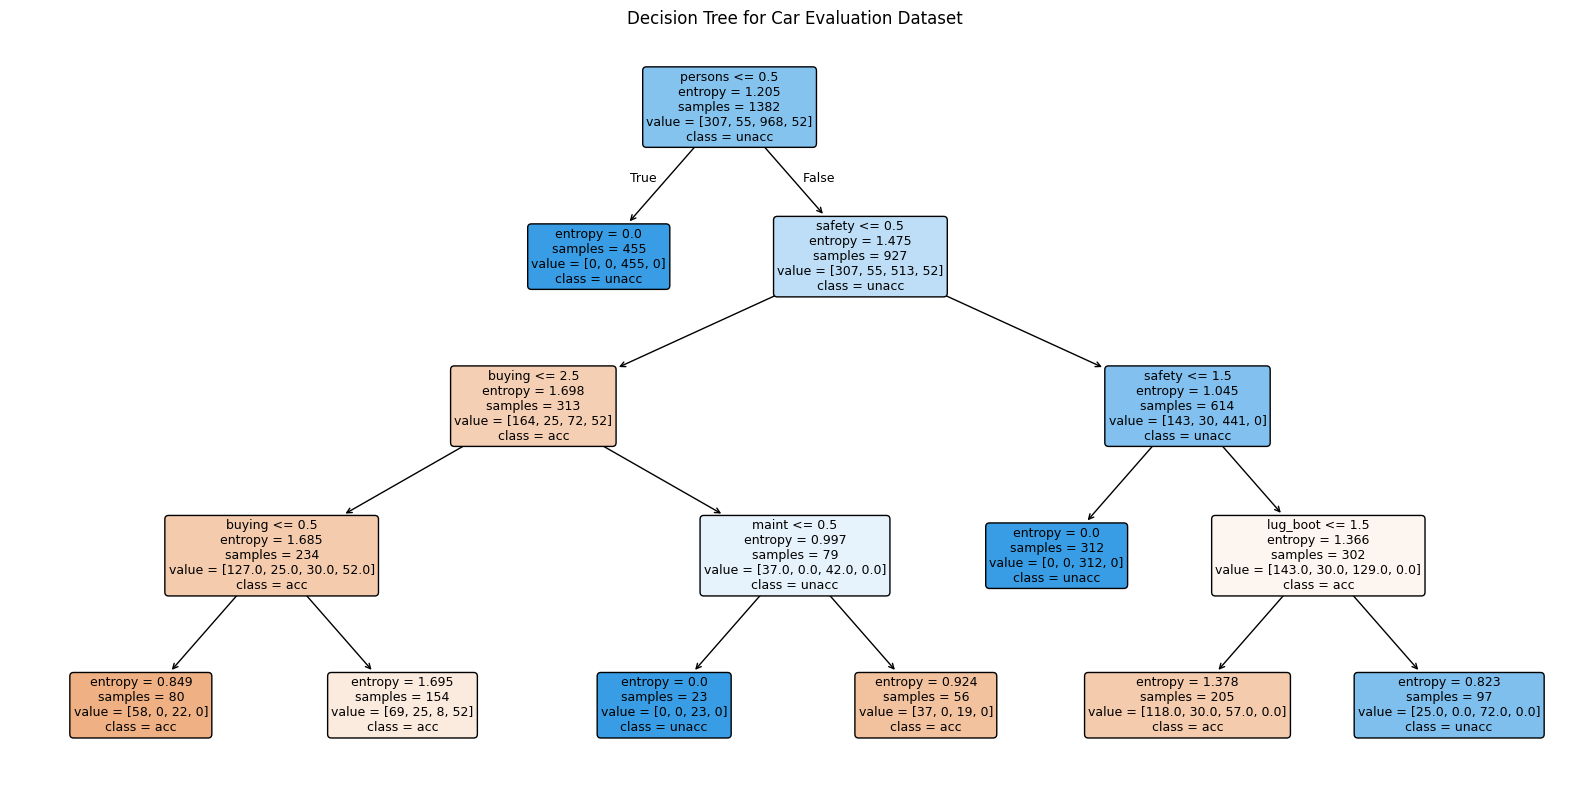

In [12]:
# 7. Plot and Save the Decision Tree Graph
plt.figure(figsize=(16, 8))
plot_tree(dt, feature_names=list(X.columns), class_names=dt.classes_, filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree for Car Evaluation Dataset")
plt.tight_layout()
plt.show()